In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import label as scipy_label
from scipy.ndimage import gaussian_filter

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [61]:
# ── User settings ─────────────────────────────────────────────────────────────
XPM_FILE       = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/nonbinders/seq1_nb/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/FE.xpm"      # Path to your .xpm file
LABEL          = "Seq1"            # System / ligand label shown in the title (e.g. "Compound_7")
TEMPERATURE    = 300           # Simulation temperature in Kelvin
BASIN_THRESH   = 5.0           # Basin detection cutoff above global min (kJ/mol)
SMOOTH_SIGMA   = 1.0           # Gaussian smoothing sigma for basin detection (grid units)
SAVE_FIGURE    = False         # Set to True to save the figure as a PNG

In [62]:
def parse_xpm(filepath):
    with open(filepath, "r") as f:
        raw   = f.read()
        lines = raw.splitlines(keepends=True)

    title, x_label, y_label, z_label = "Free Energy Landscape", "PC1 (nm)", "PC2 (nm)", "Free Energy (kJ/mol)"

    # ── 1. Parse title and axis labels (single-line comments) ─────────────────
    for line in lines:
        s = line.strip()
        if   s.startswith("/* title"):   m = re.search(r'"(.*?)"', s); title   = m.group(1) if m else title
        elif s.startswith("/* x-label"): m = re.search(r'"(.*?)"', s); x_label = m.group(1) if m else x_label
        elif s.startswith("/* y-label"): m = re.search(r'"(.*?)"', s); y_label = m.group(1) if m else y_label
        elif s.startswith("/* z-label"): m = re.search(r'"(.*?)"', s); z_label = m.group(1) if m else z_label

    # ── 2. Locate static char block ───────────────────────────────────────────
    data_start = next((i for i, l in enumerate(lines) if l.strip().startswith("static char")), 0)

    # ── 3. Parse W H N C header → defines width and height ───────────────────
    header_pattern = re.compile(r'"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)"')
    header_idx, width, height, n_colors, chars_per = 0, 0, 0, 0, 1
    for i, line in enumerate(lines[data_start:], start=data_start):
        m = header_pattern.search(line)
        
        if m:
            header_idx = i
            width, height, n_colors, chars_per = (int(m.group(k)) for k in range(1, 5))
            break

    # ── 4. Extract axis values — AFTER width/height are known ─────────────────
    def extract_axis(tag, expected_n):
        m = re.search(tag + r'(.*?)\*/', raw, re.DOTALL)
        if not m:
            return []
        vals = [float(v) for v in re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", m.group(1))]
        return vals[:expected_n]

    x_axis = extract_axis(r'/\* x-axis[:\s]*', width)
    y_axis = extract_axis(r'/\* y-axis[:\s]*', height)

    # ── 5. Hardened color → value mapping ────────────────────────────────────
    color_map = {}
    for cl in lines[header_idx + 1 : header_idx + 1 + n_colors]:
        cl = cl.strip()
        if not cl.startswith('"'):
            continue
        char_key = cl[1 : 1 + chars_per]
        comment  = re.search(r'/\*\s*(.*?)\s*\*/', cl)
        if comment:
            raw_val = comment.group(1).strip().strip('"').strip("'")
            try:
                color_map[char_key] = float(raw_val)
            except ValueError:
                color_map[char_key] = np.nan

    if not color_map:
        raise ValueError("Color map is empty — check the raw color legend lines.")

    # ── 6. Parse pixel rows ───────────────────────────────────────────────────
    rows = []
    for line in lines[header_idx + 1 + n_colors:]:
        line = line.strip()
        if not line.startswith('"'):
            continue
        content = line[1:]
        content = re.split(r'[",;]', content)[0]
        if len(content) < width * chars_per:
            continue
        row = [color_map.get(content[k : k + chars_per], np.nan)
               for k in range(0, width * chars_per, chars_per)]
        if len(row) == width:
            rows.append(row)

    if not rows:
        raise ValueError("No pixel rows parsed.")

    matrix = np.array(rows[::-1], dtype=float)
    x_axis = np.array(x_axis) if len(x_axis) == width  else np.arange(width,  dtype=float)
    y_axis = np.array(y_axis) if len(y_axis) == height else np.arange(height, dtype=float)

    return matrix, x_axis, y_axis, x_label, y_label, z_label, title

print("✓ parse_xpm defined")

✓ parse_xpm defined


In [63]:
# # ── Diagnostic: inspect raw color legend lines from FE.xpm ───────────────────
# with open(XPM_FILE, "r") as f:
#     lines = f.readlines()

# # Find the static char block
# data_start = next(i for i, l in enumerate(lines) if l.strip().startswith("static char"))

# # Find the W H N C header
# import re
# header_pattern = re.compile(r'"(\d+)\s+(\d+)\s+(\d+)\s+(\d+)"')
# for i, line in enumerate(lines[data_start:], start=data_start):
#     m = header_pattern.search(line)
#     if m:
#         header_idx = i
#         n_colors   = int(m.group(3))
#         chars_per  = int(m.group(4))
#         print(f"Header : W={m.group(1)} H={m.group(2)} N={n_colors} C={chars_per}")
#         break

# print(f"\nFirst 6 color legend lines (raw):")
# for line in lines[header_idx + 1 : header_idx + 7]:
#     print(repr(line))

In [64]:
def find_minima(matrix, x_axis, y_axis, threshold=5.0, smooth_sigma=1.0):
    """Detect conformational basins via connected-component labeling."""
    m = matrix.copy()
    finite_max = np.nanmax(m[np.isfinite(m)])
    m[~np.isfinite(m)] = finite_max
    m_smooth   = gaussian_filter(m, sigma=smooth_sigma)
    global_min = np.nanmin(m_smooth)
    occupied   = (m_smooth <= global_min + threshold).astype(int)
    labeled, n_basins = scipy_label(occupied)

    minima = []
    for basin_id in range(1, n_basins + 1):
        region = np.where(labeled == basin_id)
        idx    = np.argmin(m_smooth[region])
        yi, xi = region[0][idx], region[1][idx]
        minima.append({
            "basin_id" : basin_id,
            "x"        : float(x_axis[xi]),
            "y"        : float(y_axis[yi]),
            "value"    : float(matrix[yi, xi]),
            "n_pixels" : len(region[0]),
        })
    minima.sort(key=lambda d: d["value"])
    return minima


def compute_barriers(matrix, x_axis, y_axis, minima):
    """Estimate the free energy barrier between the two lowest basins."""
    if len(minima) < 2:
        return None
    m = matrix.copy()
    m[~np.isfinite(m)] = np.nanmax(m[np.isfinite(m)])

    xi1 = np.argmin(np.abs(x_axis - minima[0]["x"]))
    yi1 = np.argmin(np.abs(y_axis - minima[0]["y"]))
    xi2 = np.argmin(np.abs(x_axis - minima[1]["x"]))
    yi2 = np.argmin(np.abs(y_axis - minima[1]["y"]))

    n_steps  = max(abs(xi2 - xi1), abs(yi2 - yi1)) + 1
    xs = np.round(np.linspace(xi1, xi2, n_steps)).astype(int)
    ys = np.round(np.linspace(yi1, yi2, n_steps)).astype(int)
    path_vals = m[ys, xs]

    return {
        "saddle_value"    : float(np.max(path_vals)),
        "barrier_forward" : float(np.max(path_vals) - minima[0]["value"]),
        "barrier_backward": float(np.max(path_vals) - minima[1]["value"]),
        "path_x"          : x_axis[xs],
        "path_y"          : y_axis[ys],
    }


def population_weights(matrix, temp=300):
    """Boltzmann population weights from free energy (kJ/mol)."""
    RT = 8.314e-3 * temp
    m  = matrix.copy()
    m -= np.nanmin(m)
    w  = np.exp(-m / RT)
    w[~np.isfinite(w)] = 0.0
    return w / w.sum()


print("✓ Analysis helpers defined")

✓ Analysis helpers defined


In [65]:
matrix, x_axis, y_axis, x_label, y_label, z_label, title = parse_xpm(XPM_FILE)

# Guard: check the matrix actually has finite values
finite_vals = matrix[np.isfinite(matrix)]
if finite_vals.size == 0:
    raise ValueError(
        "Matrix contains no finite values after parsing.\n"
        "Check that the hardened parse_xpm (Cell 3) is being used, "
        "then re-run from Cell 3 downward."
    )

fe_min = float(np.nanmin(matrix))
fe_max = float(np.nanmax(finite_vals))

print(f"File    : {XPM_FILE}")
print(f"Grid    : {matrix.shape[1]} (PC1) × {matrix.shape[0]} (PC2) points")
print(f"PC1     : {x_axis[0]:.3f} → {x_axis[-1]:.3f} nm")
print(f"PC2     : {y_axis[0]:.3f} → {y_axis[-1]:.3f} nm")
print(f"FE range: {fe_min:.4f} – {fe_max:.4f} kJ/mol")
print(f"Color map size: {25} entries  ✓")

# Sanity: show how many cells are finite vs NaN
n_total  = matrix.size
n_finite = finite_vals.size
n_nan    = n_total - n_finite
print(f"Finite cells: {n_finite}/{n_total}  |  NaN (unsampled): {n_nan}")

File    : /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/nonbinders/seq1_nb/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/FE.xpm
Grid    : 32 (PC1) × 32 (PC2) points
PC1     : -4.466 → 2.564 nm
PC2     : -2.912 → 2.465 nm
FE range: 0.0000 – 1.0000 kJ/mol
Color map size: 25 entries  ✓
Finite cells: 1024/1024  |  NaN (unsampled): 0


In [66]:
minima   = find_minima(matrix, x_axis, y_axis,
                       threshold=BASIN_THRESH, smooth_sigma=SMOOTH_SIGMA)
barriers = compute_barriers(matrix, x_axis, y_axis, minima)

# ── Print report ──────────────────────────────────────────────────────────────
header = f"Free Energy Analysis Report{'  —  ' + LABEL if LABEL else ''}"
print(f"\n{'═'*len(header)}")
print(header)
print(f"{'═'*len(header)}")

if not minima:
    print("  No basins detected — try lowering BASIN_THRESH.")
else:
    print(f"\n  Conformational Basins ({len(minima)} found):\n")
    print(f"  {'Basin':<8} {'PC1 (nm)':>10} {'PC2 (nm)':>10} "
          f"{'FE (kJ/mol)':>13} {'ΔFE':>8} {'Size (pts)':>11}")
    print("  " + "─" * 64)
    for mn in minima:
        print(f"  B{mn['basin_id']:<7} {mn['x']:>10.3f} {mn['y']:>10.3f} "
              f"{mn['value']:>13.2f} {mn['value'] - minima[0]['value']:>8.2f} "
              f"{mn['n_pixels']:>11}")

if barriers:
    print(f"\n  B1 → B2 Saddle:")
    print(f"    Saddle FE       : {barriers['saddle_value']:.2f} kJ/mol")
    print(f"    ΔG‡ (B1 → B2)  : {barriers['barrier_forward']:.2f} kJ/mol")
    print(f"    ΔG‡ (B2 → B1)  : {barriers['barrier_backward']:.2f} kJ/mol")

# ── Interpretation hint ───────────────────────────────────────────────────────
print()
if len(minima) == 1:
    print("  💡 Single deep basin → stable, converged dynamics.")
    print("     Consistent with a binder locking the protein into one conformation.")
elif len(minima) >= 3:
    print("  💡 Multiple shallow basins → diffuse landscape.")
    print("     Consistent with a non-binder or weak binder sampling many conformations.")
elif len(minima) == 2:
    df = minima[1]["value"] - minima[0]["value"]
    if df < 5:
        print("  💡 Two similarly populated basins → induced-fit or conformational selection.")
    else:
        print("  💡 One dominant basin + one minor state → strong binder with rare excursion.")


════════════════════════════════════
Free Energy Analysis Report  —  Seq1
════════════════════════════════════

  Conformational Basins (1 found):

  Basin      PC1 (nm)   PC2 (nm)   FE (kJ/mol)      ΔFE  Size (pts)
  ────────────────────────────────────────────────────────────────
  B1            1.203      0.383          0.00     0.00        1024

  💡 Single deep basin → stable, converged dynamics.
     Consistent with a binder locking the protein into one conformation.


/var/folders/b1/77x_k7v964g1hhhp9pz24yr40000gn/T/ipykernel_35019/3557274424.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


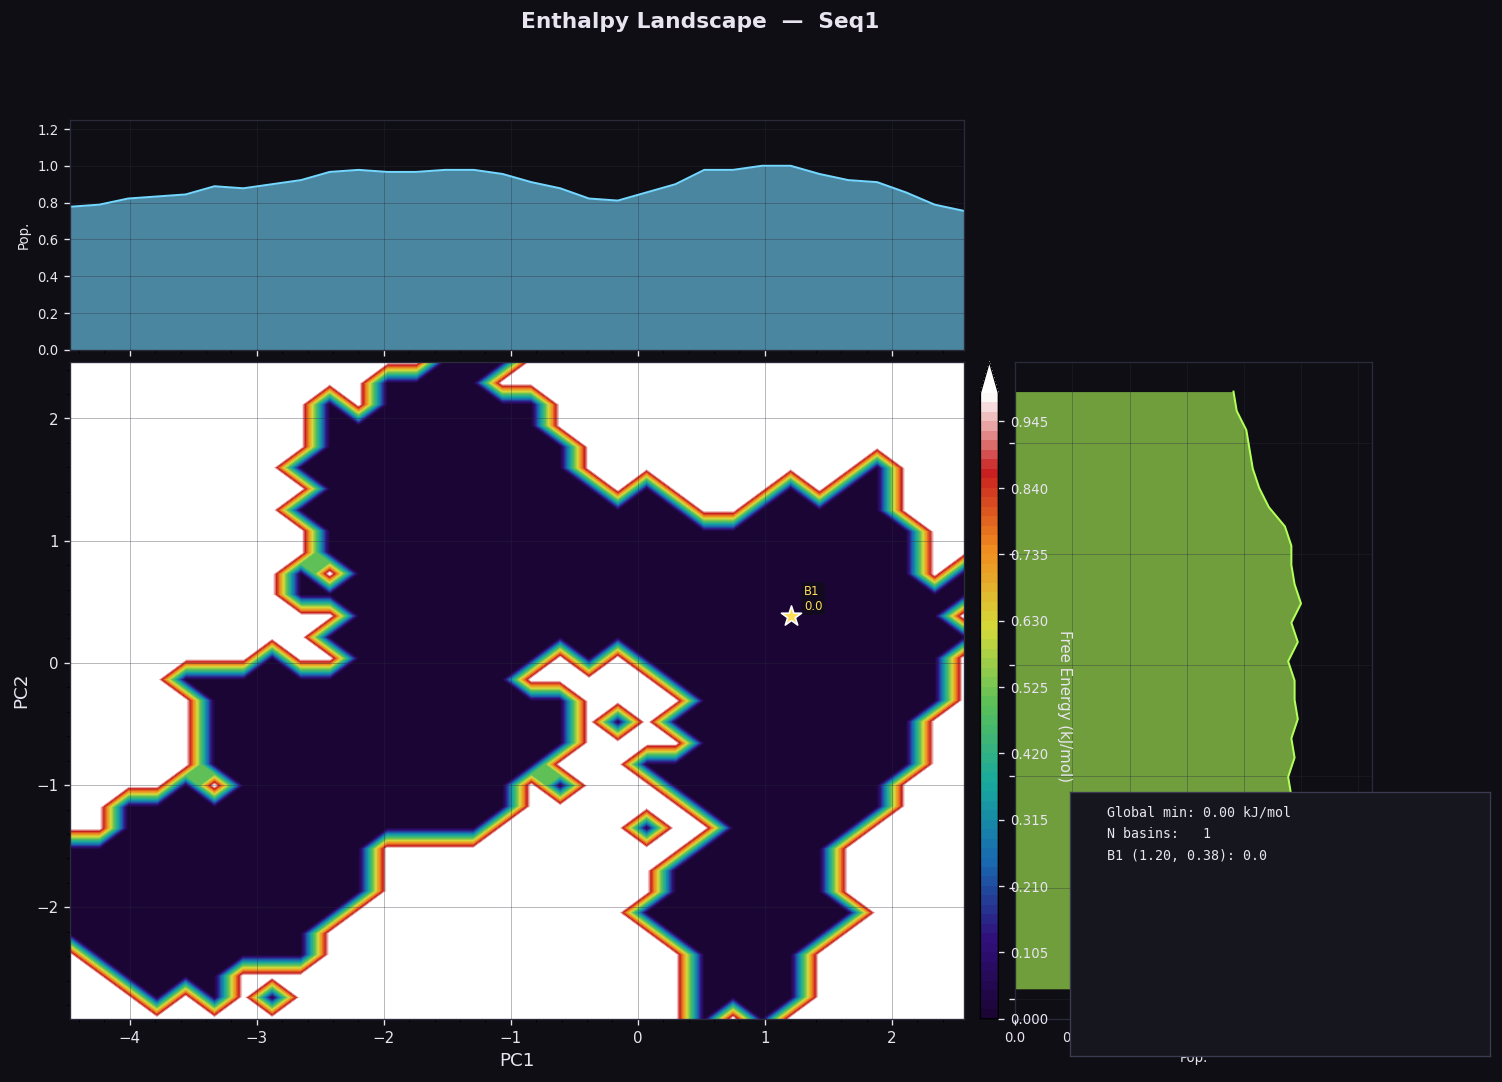

In [67]:
GROMACS_CMAP = LinearSegmentedColormap.from_list(
    "gromacs_fe",
    ["#1a0533", "#30107a", "#1967b0", "#17a89e",
     "#5abf5a", "#d4d93a", "#f08c20", "#c82020", "#ffffff"],
)

panel_bg = "#0e0e14"
text_col = "#e8e4f0"
grid_col = "#2a2a3a"

fig = plt.figure(figsize=(14, 10), facecolor=panel_bg)
gs  = fig.add_gridspec(
    3, 3,
    width_ratios=[4, 0.08, 1.6],
    height_ratios=[1.4, 4, 0.08],
    hspace=0.04, wspace=0.04,
)
ax_main  = fig.add_subplot(gs[1, 0])
ax_top   = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 2])
ax_cbar  = fig.add_subplot(gs[1, 1])
ax_stats = fig.add_axes([0.72, 0.10, 0.25, 0.22], facecolor="#16161f")

for ax in [ax_main, ax_top, ax_right]:
    ax.set_facecolor(panel_bg)
    ax.tick_params(colors=text_col, labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(grid_col)

# ── Prepare data ──────────────────────────────────────────────────────────────
m = matrix.copy()
finite_mask = np.isfinite(m)
vmin   = np.nanmin(m[finite_mask])
vmax   = min(np.nanpercentile(m[finite_mask], 99), vmin + 40)
m_plot = np.clip(m, vmin, vmax)
X, Y   = np.meshgrid(x_axis, y_axis)

# ── Main contour fill ─────────────────────────────────────────────────────────
cf = ax_main.contourf(X, Y, m_plot, levels=80, cmap=GROMACS_CMAP, extend="max")

iso_levels = [vmin + v for v in [2, 5, 10, 20] if vmin + v <= vmax]
if iso_levels:
    cs = ax_main.contour(X, Y, m_plot, levels=iso_levels,
                         colors="white", linewidths=0.6, alpha=0.5)
    ax_main.clabel(cs, fmt="%.0f", fontsize=7, colors="white")

# ── Basin minima ──────────────────────────────────────────────────────────────
marker_colors = ["#ffdd57", "#ff6b6b", "#74d7ff", "#b2ff59", "#ff9ef5"]
for i, mn in enumerate(minima[:5]):
    col = marker_colors[i % len(marker_colors)]
    ax_main.scatter(mn["x"], mn["y"], s=160, color=col,
                    edgecolors="white", linewidths=1.0, zorder=5, marker="*")
    ax_main.annotate(
        f"B{i+1}\n{mn['value']:.1f}",
        (mn["x"], mn["y"]),
        textcoords="offset points", xytext=(8, 4),
        fontsize=7, color=col,
        bbox=dict(boxstyle="round,pad=0.2", fc="#0e0e14aa", ec="none"),
    )

# ── Barrier path ──────────────────────────────────────────────────────────────
if barriers:
    ax_main.plot(barriers["path_x"], barriers["path_y"],
                 color="#ffffffaa", lw=1.5, ls="--")

ax_main.set_xlabel(x_label, color=text_col, fontsize=11)
ax_main.set_ylabel(y_label, color=text_col, fontsize=11)
ax_main.tick_params(axis="both", colors=text_col)
ax_main.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_main.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_main.grid(visible=True, color=grid_col, lw=0.4, alpha=0.5)

# ── Colorbar ──────────────────────────────────────────────────────────────────
cbar = plt.colorbar(cf, cax=ax_cbar)
cbar.set_label(z_label, color=text_col, fontsize=9, rotation=270, labelpad=14)
cbar.ax.tick_params(colors=text_col, labelsize=8)
plt.setp(ax_cbar.yaxis.get_ticklabels(), color=text_col)

# ── Marginal: PC1 (top) ───────────────────────────────────────────────────────
weights = population_weights(matrix, temp=TEMPERATURE)
pop_x   = weights.sum(axis=0)
pop_x  /= pop_x.max()
ax_top.fill_between(x_axis, pop_x, alpha=0.6, color="#74d7ff", linewidth=0)
ax_top.plot(x_axis, pop_x, color="#74d7ff", lw=1.2)
ax_top.set_ylabel("Pop.", color=text_col, fontsize=8)
ax_top.tick_params(labelbottom=False, colors=text_col, labelsize=8)
ax_top.set_ylim(0, 1.25)
ax_top.grid(visible=True, color=grid_col, lw=0.4, alpha=0.5)

# ── Marginal: PC2 (right) ─────────────────────────────────────────────────────
pop_y  = weights.sum(axis=1)
pop_y /= pop_y.max()
ax_right.fill_betweenx(y_axis, pop_y, alpha=0.6, color="#b2ff59", linewidth=0)
ax_right.plot(pop_y, y_axis, color="#b2ff59", lw=1.2)
ax_right.set_xlabel("Pop.", color=text_col, fontsize=8)
ax_right.tick_params(labelleft=False, colors=text_col, labelsize=8)
ax_right.set_xlim(0, 1.25)
ax_right.grid(visible=True, color=grid_col, lw=0.4, alpha=0.5)

# ── Stats inset ───────────────────────────────────────────────────────────────
for spine in ax_stats.spines.values():
    spine.set_edgecolor("#3a3a50")
ax_stats.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

stats_lines = [f"  Global min: {vmin:.2f} kJ/mol",
               f"  N basins:   {len(minima)}"]
for i, mn in enumerate(minima[:3]):
    stats_lines.append(f"  B{i+1} ({mn['x']:.2f}, {mn['y']:.2f}): {mn['value']:.1f}")
if barriers:
    stats_lines.append(f"  ΔG‡ (fwd):  {barriers['barrier_forward']:.1f} kJ/mol")
    stats_lines.append(f"  ΔG‡ (bwd):  {barriers['barrier_backward']:.1f} kJ/mol")

ax_stats.text(0.05, 0.95, "\n".join(stats_lines),
              transform=ax_stats.transAxes, va="top", ha="left",
              fontsize=8, color=text_col, family="monospace", linespacing=1.7)

# ── Title & layout ────────────────────────────────────────────────────────────
suptitle = title + (f"  —  {LABEL}" if LABEL else "")
fig.suptitle(suptitle, color=text_col, fontsize=13, y=0.97, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])

if SAVE_FIGURE:
    outname = f"FE{'_' + LABEL.replace(' ', '_') if LABEL else ''}.png"
    fig.savefig(outname, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"Saved: {outname}")

plt.show()

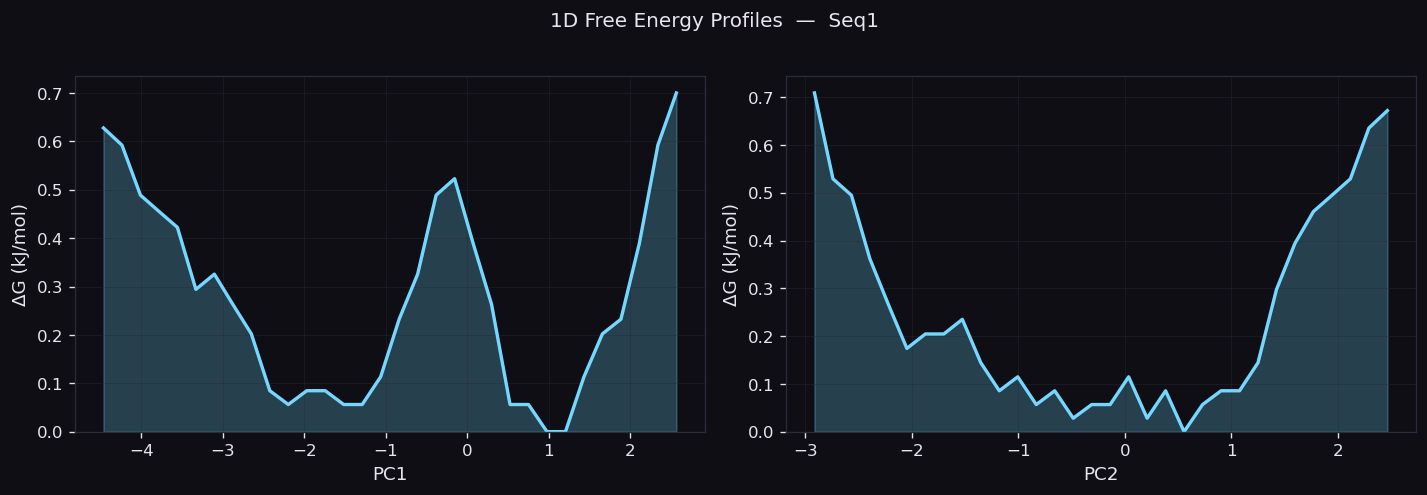

In [68]:
RT = 8.314e-3 * TEMPERATURE

# Boltzmann-weighted marginal populations
weights = population_weights(matrix, temp=TEMPERATURE)
pop_x   = weights.sum(axis=0)    # marginal over PC2 → function of PC1
pop_y   = weights.sum(axis=1)    # marginal over PC1 → function of PC2

# Convert population to free energy:  G = -RT ln(p)
with np.errstate(divide="ignore"):
    fe_x = -RT * np.log(np.where(pop_x > 0, pop_x, np.nan))
    fe_y = -RT * np.log(np.where(pop_y > 0, pop_y, np.nan))

fe_x -= np.nanmin(fe_x)
fe_y -= np.nanmin(fe_y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), facecolor=panel_bg)

for ax, xdata, fedata, pc_label in [
    (ax1, x_axis, fe_x, x_label),
    (ax2, y_axis, fe_y, y_label),
]:
    ax.set_facecolor(panel_bg)
    ax.fill_between(xdata, fedata, alpha=0.25, color="#74d7ff")
    ax.plot(xdata, fedata, color="#74d7ff", lw=2)
    ax.set_xlabel(pc_label, color=text_col, fontsize=11)
    ax.set_ylabel("ΔG (kJ/mol)", color=text_col, fontsize=11)
    ax.tick_params(colors=text_col)
    ax.grid(visible=True, color=grid_col, lw=0.4, alpha=0.6)
    for spine in ax.spines.values():
        spine.set_edgecolor(grid_col)
    ax.set_ylim(bottom=0)

fig.suptitle("1D Free Energy Profiles" + (f"  —  {LABEL}" if LABEL else ""),
             color=text_col, fontsize=12, y=1.02)
plt.tight_layout()

if SAVE_FIGURE:
    fig.savefig(f"FE_1D{'_' + LABEL.replace(' ','_') if LABEL else ''}.png",
                dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

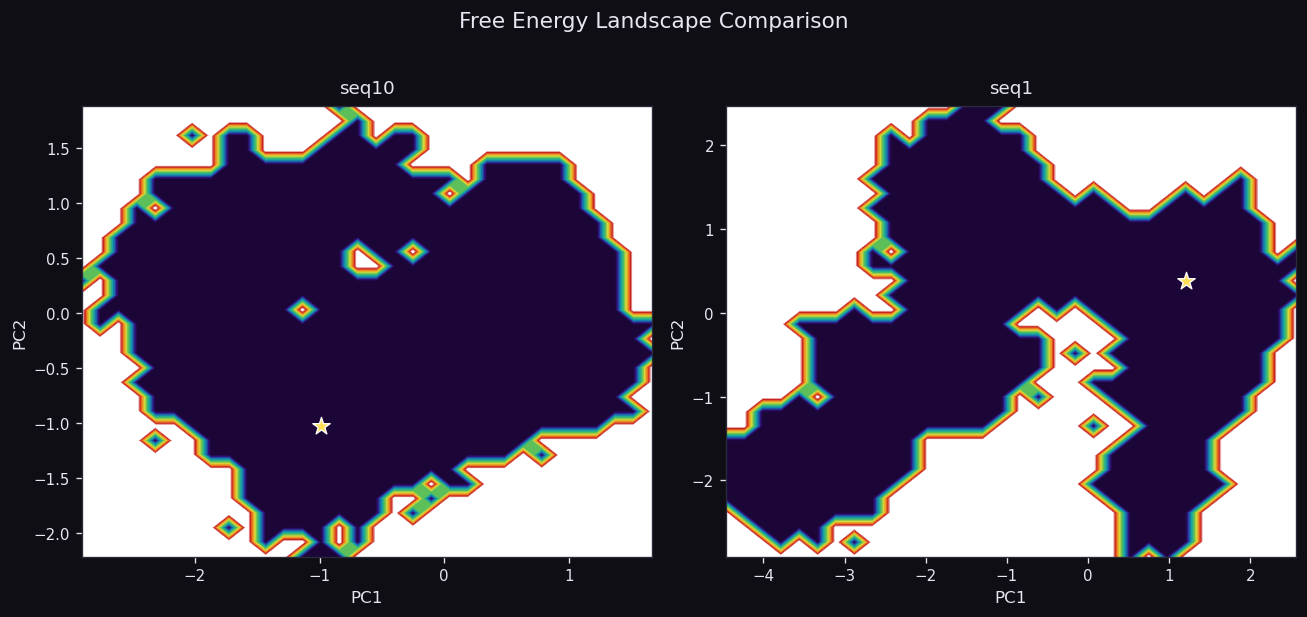

In [69]:
# ── Edit this list to compare multiple systems ────────────────────────────────
datasets = [
    {"xpm_file": "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/binders/seq10_binder/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/FE.xpm", "label": "seq10"},
    {"xpm_file": "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/nonbinders/seq1_nb/prod_md_0p9_cutoff_3dt_64x1_16PME_642dd/FE.xpm",  "label": "seq1"},
    # {"xpm_file": "binder2/FE.xpm",    "label": "Binder C"},
]

n    = len(datasets)
fig2, axes = plt.subplots(1, n, figsize=(5.5 * n, 5),
                           facecolor=panel_bg, sharey=False)
if n == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets):
    mat, xa, ya, xl, yl, zl, ttl = parse_xpm(ds["xpm_file"])
    fm  = np.isfinite(mat)
    v0  = np.nanmin(mat[fm])
    v1  = min(np.nanpercentile(mat[fm], 99), v0 + 40)
    Xc, Yc = np.meshgrid(xa, ya)
    ax.contourf(Xc, Yc, np.clip(mat, v0, v1), levels=60,
                cmap=GROMACS_CMAP, extend="max")
    mn_list = find_minima(mat, xa, ya)
    if mn_list:
        ax.scatter([mn["x"] for mn in mn_list[:3]],
                   [mn["y"] for mn in mn_list[:3]],
                   s=120, color="#ffdd57", edgecolors="white",
                   linewidths=0.8, zorder=5, marker="*")
    ax.set_facecolor(panel_bg)
    ax.tick_params(colors=text_col, labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(grid_col)
    ax.set_xlabel(xl, color=text_col, fontsize=10)
    ax.set_ylabel(yl, color=text_col, fontsize=10)
    ax.set_title(ds.get("label", ttl), color=text_col, fontsize=11, pad=8)

fig2.suptitle("Free Energy Landscape Comparison",
              color=text_col, fontsize=13, y=1.02)
plt.tight_layout()

if SAVE_FIGURE:
    fig2.savefig("FE_comparison.png", dpi=200,
                 bbox_inches="tight", facecolor=fig2.get_facecolor())
plt.show()

- For each frame, plot the amount of each PC